In [1]:
import pandas as pd 
import numpy as np

In [31]:
df = pd.read_csv('employee_outliers_5000.csv')

In [5]:
df.head()

,employee_id,name,age,gender,city,education,department,job_title,job_type,experience_yrs,tenure_yrs,salary,bonus,overtime_hrs,performance,rating,score,join_date
0,EMP1000,Hassan Javed,29,Female,Karachi,Bachelor,Finance,Senior Manager,Part-time,0,10,112097,8350,6,Excellent,4.0,84,2013-02-17
1,EMP1001,Khalid Qureshi,34,Female,Multan,PhD,HR,Senior Manager,Contract,11,0,149974,10805,17,Excellent,4.4,50,2023-03-21
2,EMP1002,Yusuf Baig,27,Male,Faisalabad,Bachelor,Marketing,Associate,Part-time,3,6,65353,5614,38,Excellent,2.8,52,2017-09-18
3,EMP1003,Faisal Baig,24,Female,Islamabad,PhD,Operations,Senior Manager,Contract,2,12,99742,12698,14,Excellent,4.6,74,2011-10-16
4,EMP1004,Ibrahim Iqbal,32,Male,Multan,Bachelor,Sales,Analyst,Contract,8,5,104175,6911,17,Poor,5.0,90,2018-07-06


In [6]:
import seaborn as sns

<Axes: ylabel='age'>

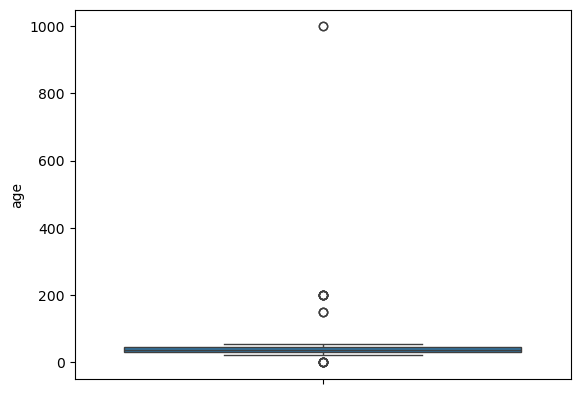

In [8]:
sns.boxplot(df['age'])

### Using IQR

### Removing outliers

In [9]:
lower_limit=df['age'].quantile(0.25)
upper_limit = df['age'].quantile(0.75)

In [10]:
IQR = upper_limit - lower_limit
lower = lower_limit - 1.5*IQR
upper = upper_limit + 1.5*IQR

In [18]:
df_new = df[(df['age']<upper) & (df['age']>lower)]


### Capping

In [33]:
df_new_capping= np.where(
    df['age']>upper,upper,
    np.where(df['age']<lower, lower,
            df['age']
            )
)

In [38]:
df['age']=df_new_capping


### Using ZScore method

### Removing outliers method

In [26]:
std = df['age'].std()
mean = df['age'].mean()
highest = (df['age'] + 3*mean) / std
lowest = (df['age'] - 3*mean) / std

In [40]:
df[(df['age']>lowest) & (df['age']<highest)]

,employee_id,name,age,gender,city,education,department,job_title,job_type,experience_yrs,tenure_yrs,salary,bonus,overtime_hrs,performance,rating,score,join_date
440,EMP1440,Ali Baig,4.5,Female,Rawalpindi,Intermediate,Customer Support,Senior Analyst,Part-time,8,4,82874,9994,7,Excellent,5.0,81,2019-10-16
1414,EMP2414,Hassan Mirza,4.5,Female,Faisalabad,Diploma,Sales,Senior Manager,Part-time,17,6,43263,2819,10,Average,3.8,71,2017-03-20
1780,EMP2780,Naveed Rizvi,4.5,Female,Lahore,PhD,Sales,Analyst,Part-time,9,6,103532,13812,39,Good,3.3,76,2017-03-31
1903,EMP2903,Usman Baig,4.5,Female,Lahore,Diploma,Sales,Director,Remote,3,13,149038,22277,21,Good,4.9,77,2010-01-27
3014,EMP4014,Raza Ansari,4.5,Female,Quetta,PhD,Finance,Analyst,Contract,19,5,49120,3988,4,Good,2.2,89,2018-07-11
3510,EMP4510,Rabia Baig,4.5,Male,Islamabad,Master,Finance,Specialist,Full-time,13,13,74496,10592,30,Poor,4.3,61,2010-01-13
3788,EMP4788,Sana Iqbal,4.5,Male,Multan,Master,HR,Director,Remote,7,1,174066,21907,7,Excellent,4.2,100,2022-04-09
4552,EMP5552,Rabia Raza,4.5,Male,Rawalpindi,Diploma,Operations,Engineer,Full-time,8,1,122579,13381,1,Poor,3.2,53,2022-02-10


### Capping Outliers method

In [52]:
std1 = df['experience_yrs'].std()
mean1 = df['experience_yrs'].mean()
upper_limit_experience_yrs = (df['experience_yrs'] + 3*mean1) / std1
lower_limit_experience_yrs= (df['experience_yrs']  - 3*mean1) / std1

In [53]:
df['experience_yrs'] = np.where(
    df['experience_yrs']>upper_limit_experience_yrs, upper_limit_experience_yrs,
    np.where(df['experience_yrs']<lower_limit_experience_yrs, lower_limit_experience_yrs,
            df['experience_yrs']
            )
)

### Winsorization


In [111]:
upper_bonus = df['bonus'].quantile(0.99)
lower_bonus = df['bonus'].quantile(0.01)

### Removing outliers


In [115]:
df=df[((df['bonus']<upper_bonus) & (df['bonus']>lower_bonus))]

In [116]:
df

,employee_id,name,age,gender,city,education,department,job_title,job_type,experience_yrs,tenure_yrs,salary,bonus,overtime_hrs,performance,rating,score,join_date
0,EMP1000,Hassan Javed,29.0,Female,Karachi,Bachelor,Finance,Senior Manager,Part-time,0.000000,10,4.222136,8350,6,Excellent,4.0,84,2013-02-17
1,EMP1001,Khalid Qureshi,34.0,Female,Multan,PhD,HR,Senior Manager,Contract,4.095491,0,4.563169,10805,17,Excellent,4.4,50,2023-03-21
2,EMP1002,Yusuf Baig,27.0,Male,Faisalabad,Bachelor,Marketing,Associate,Part-time,3.000000,6,3.801267,5614,38,Excellent,2.8,52,2017-09-18
3,EMP1003,Faisal Baig,24.0,Female,Islamabad,PhD,Operations,Senior Manager,Contract,2.000000,12,4.110895,12698,14,Excellent,4.6,74,2011-10-16
4,EMP1004,Ibrahim Iqbal,32.0,Male,Multan,Bachelor,Sales,Analyst,Contract,3.755087,5,4.150809,6911,17,Poor,5.0,90,2018-07-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,EMP5995,Tariq Shah,54.0,Female,Lahore,Intermediate,Legal,Manager,Remote,6.137915,10,4.474951,14621,18,Good,3.1,90,2013-05-09
4996,EMP5996,Ahmed Hussain,43.0,Female,Lahore,Intermediate,Sales,Senior Manager,Full-time,4.435895,2,4.336897,9942,18,Average,3.0,69,2021-06-11
4997,EMP5997,Usman Baig,33.0,Male,Multan,PhD,Marketing,Director,Full-time,1.000000,8,4.300009,11681,33,Good,2.1,62,2015-04-29
4998,EMP5998,Asad Raza,53.0,Male,Karachi,Intermediate,IT,Director,Part-time,4.889767,10,3.793470,9066,16,Poor,2.7,50,2013-11-20


### Winsorization / Capping

In [118]:
df['bonus'] = np.where(
    df['bonus']>upper_bonus, upper_bonus,
    np.where(
        df['bonus']<lower_bonus, lower_bonus,
        df['bonus']
    )
)

C:\Users\essas\AppData\Local\Temp\ipykernel_14392\3087334685.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bonus'] = np.where(


In [119]:
df['bonus'].sample(10)

2645    10439.0
4765    15177.0
1163     5957.0
2689    20237.0
3587    13391.0
807     15432.0
3528    10525.0
3013    11223.0
3669    14631.0
4072     4623.0
Name: bonus, dtype: float64